# Phase 11 — Risk Attribution

**Three questions:**
1. Which ETF contributes most **return**?
2. Which ETF contributes most **risk**?
3. Which ETF **hurts** performance?

**Method**: Brinson-style return attribution + Component Risk Contribution (CRC) decomposition + drawdown attribution.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from src.data import load_prices, compute_returns
from src.signals import load_signals
from src.risk_attribution import run_risk_attribution

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


In [2]:
prices  = load_prices(directory='../data/processed')
returns = compute_returns(prices)
signals = load_signals(directory='../data/processed')

res = run_risk_attribution(signals, prices, returns, proc_dir='../data/processed')

summary      = res['summary']
weights      = res['weights']
ret_contrib  = res['ret_contrib']
risk_contrib = res['risk_contrib']
dd_res       = res['dd_res']

# Keep only ETFs that appear in the portfolio at least 5% of the time
active = summary[summary['Freq % (in portfolio)'] >= 5].copy()
active_tickers = active.index.tolist()
print(f'Active ETFs (held ≥5% of months): {active_tickers}')


  RISK ATTRIBUTION — Momentum → Top-5 → 200DMA → HRP

  1. RETURN ATTRIBUTION
  ETF        Cum%     Ann%    Freq%   AvgWt(held)  Role
  ────── ────────  ───────  ───────  ────────────  ────────────────────
  GLD       42.61%    1.98%    40.3%         24.2%  ★ TOP CONTRIBUTOR
  QQQ       31.34%    1.46%    60.1%         17.0%  ★ TOP CONTRIBUTOR
  EEM       30.17%    1.40%    32.9%         20.5%  ★ TOP CONTRIBUTOR
  SPY       25.80%    1.20%    48.4%         19.7%  ★ TOP CONTRIBUTOR
  DBC       22.92%    1.07%    20.2%         26.6%  ★ TOP CONTRIBUTOR
  VGK       16.18%    0.75%    33.3%         20.3%  ★ TOP CONTRIBUTOR
  SLV       15.26%    0.71%    32.2%          9.5%  ★ TOP CONTRIBUTOR
  IEF       12.46%    0.58%    20.5%         41.2%  ★ TOP CONTRIBUTOR
  TLT       10.42%    0.48%    21.7%         18.7%  ★ TOP CONTRIBUTOR
  IWM       10.06%    0.47%    38.0%         17.0%  ★ TOP CONTRIBUTOR
  VNQ        6.76%    0.32%    40.3%         16.2%  ★ TOP CONTRIBUTOR
  BIL        4.05%    0

## 1. Return Attribution

Cumulative return contribution = sum of monthly `weight × return` per ETF over the full period.

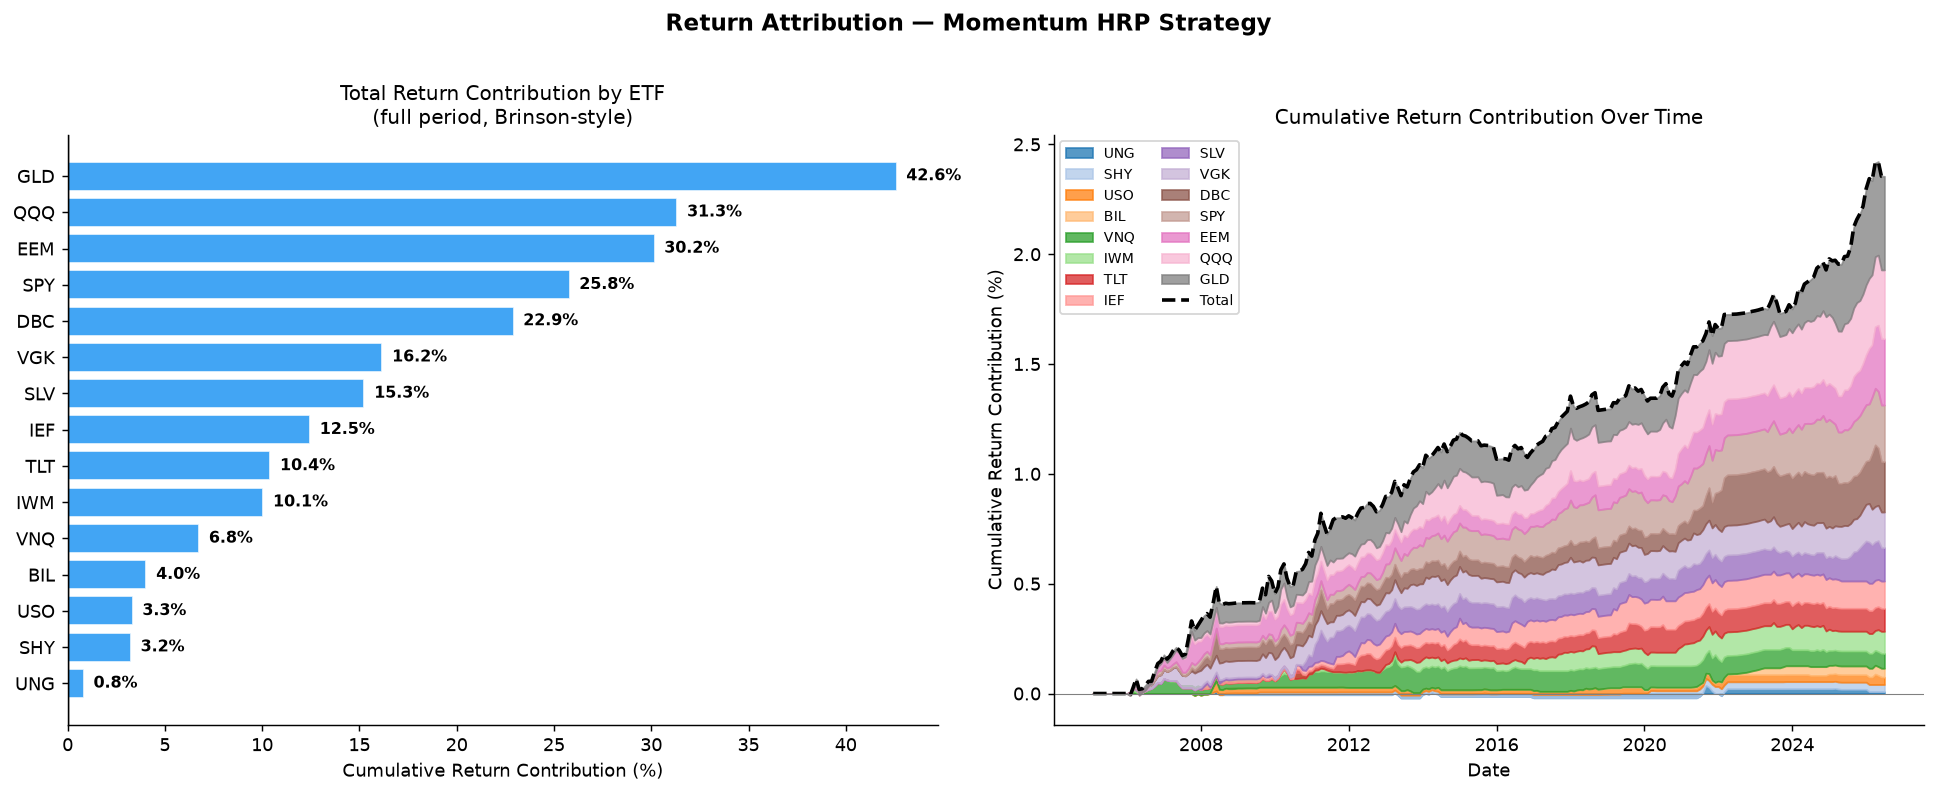


Key finding: GLD, QQQ, EEM are the top 3 return contributors.
Together they explain: 104.1 % of total return


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Horizontal bar chart — total return contribution
ax = axes[0]
ret_sorted = active.sort_values('Cum Return Contrib %')
ticks = ret_sorted.index.tolist()
vals  = ret_sorted['Cum Return Contrib %'].values
cols  = ['#2196F3' if v >= 0 else '#F44336' for v in vals]
bars  = ax.barh(ticks, vals, color=cols, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for b, v in zip(bars, vals):
    x = v + 0.5 if v >= 0 else v - 0.5
    ha = 'left' if v >= 0 else 'right'
    ax.text(x, b.get_y() + b.get_height()/2, f'{v:.1f}%', va='center', ha=ha, fontsize=9, fontweight='bold')
ax.set_xlabel('Cumulative Return Contribution (%)')
ax.set_title('Total Return Contribution by ETF\n(full period, Brinson-style)')

# Stacked area — cumulative contribution over time
ax = axes[1]
cum_contrib = ret_contrib[active_tickers].cumsum()
# Sort by final value for stacking order
final_vals = cum_contrib.iloc[-1].sort_values()
palette = plt.cm.tab20.colors
pos_tickers = final_vals[final_vals >= 0].index.tolist()
neg_tickers = final_vals[final_vals < 0].index.tolist()

bottom_pos = np.zeros(len(cum_contrib))
for i, tkr in enumerate(pos_tickers):
    vals_t = cum_contrib[tkr].values
    ax.fill_between(cum_contrib.index, bottom_pos, bottom_pos + vals_t,
                    alpha=0.75, label=tkr, color=palette[i % len(palette)])
    bottom_pos += vals_t

ax.plot(cum_contrib.sum(axis=1).index, cum_contrib.sum(axis=1).values,
        color='black', linewidth=2, label='Total', linestyle='--')
ax.axhline(0, color='gray', linewidth=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return Contribution (%)')
ax.set_title('Cumulative Return Contribution Over Time')
ax.legend(fontsize=7.5, ncol=2, loc='upper left')

fig.suptitle('Return Attribution — Momentum HRP Strategy', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nKey finding: GLD, QQQ, EEM are the top 3 return contributors.')
print('Together they explain:', active.loc[['GLD','QQQ','EEM'], 'Cum Return Contrib %'].sum().round(1), '% of total return')

## 2. Risk Attribution — Component Risk Contribution

CRC_i = w_i × (Σw)_i / σ_p. Components **sum to portfolio volatility** at each date.

The HRP algorithm is designed to equalize risk contributions — a good allocation should show Risk/Weight ≈ 1.0 for all assets.

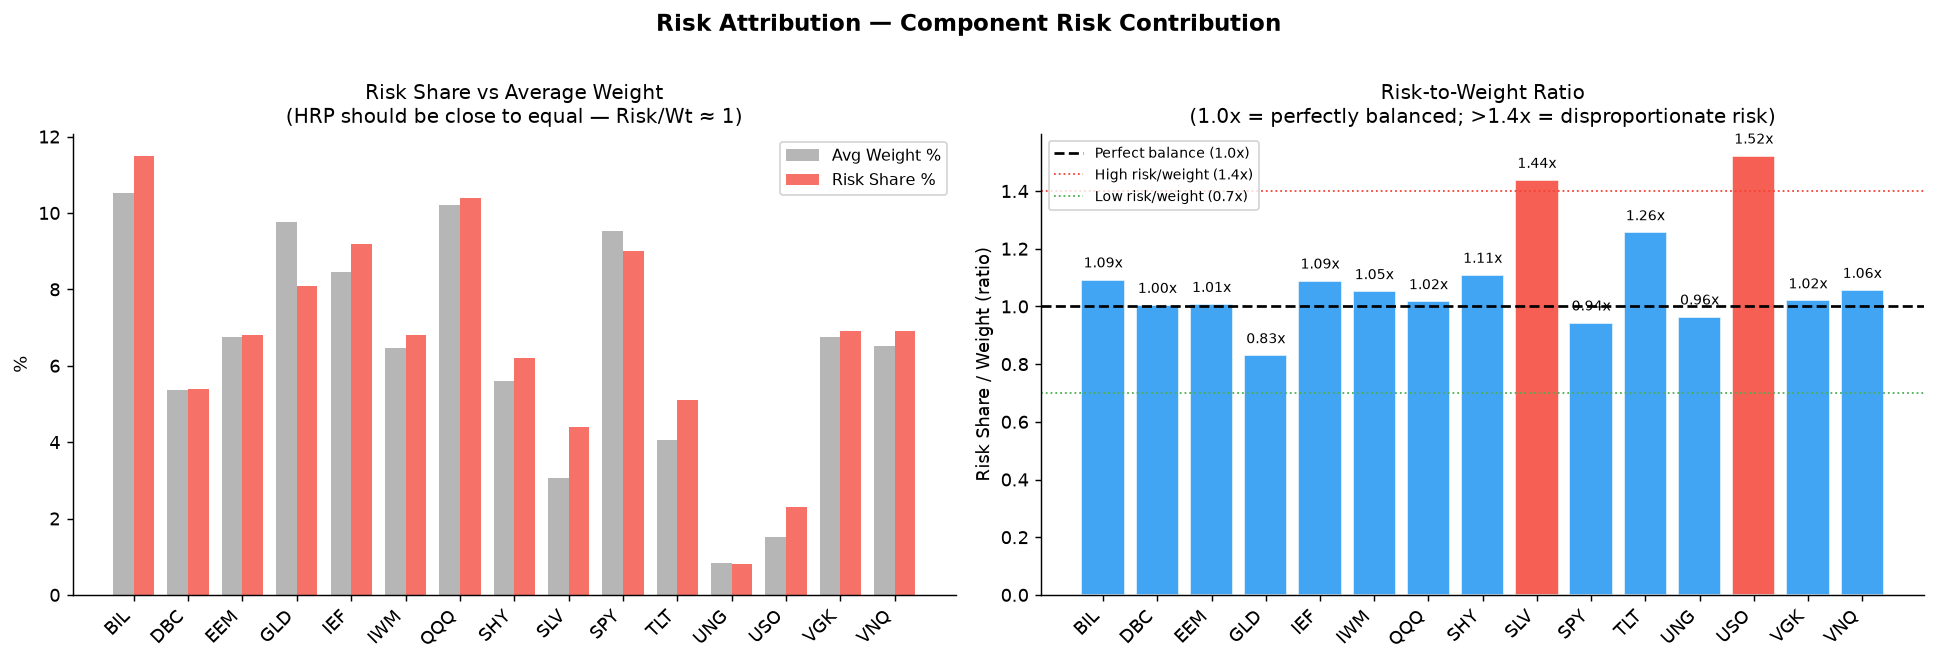

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Risk Share vs Weight comparison
ax = axes[0]
x  = np.arange(len(active_tickers))
w  = 0.38

# Average weight across ALL months (not just when held)
avg_wt_all = (active['Freq % (in portfolio)'] * active['Avg Wt When Held %'] / 100)
risk_sh    = active['Risk Share %']

ax.bar(x - w/2, avg_wt_all.values, w, label='Avg Weight %', color='#9E9E9E', alpha=0.75)
ax.bar(x + w/2, risk_sh.values,    w, label='Risk Share %', color='#F44336', alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(active_tickers, rotation=45, ha='right')
ax.set_ylabel('%')
ax.set_title('Risk Share vs Average Weight\n(HRP should be close to equal — Risk/Wt ≈ 1)')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

# Risk/Weight ratio — deviation from 1.0 means over/under-contributing to risk
ax = axes[1]
ratio = (risk_sh / avg_wt_all).replace([np.inf, -np.inf], np.nan).fillna(0)
cols  = ['#F44336' if v > 1.4 else ('#4CAF50' if v < 0.7 else '#2196F3') for v in ratio.values]
ax.bar(x, ratio.values, color=cols, alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--', label='Perfect balance (1.0x)')
ax.axhline(1.4, color='#F44336', linewidth=1, linestyle=':', label='High risk/weight (1.4x)')
ax.axhline(0.7, color='#4CAF50', linewidth=1, linestyle=':', label='Low risk/weight (0.7x)')
for i, (v, tkr) in enumerate(zip(ratio.values, active_tickers)):
    ax.text(i, v + 0.03, f'{v:.2f}x', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(active_tickers, rotation=45, ha='right')
ax.set_ylabel('Risk Share / Weight (ratio)')
ax.set_title('Risk-to-Weight Ratio\n(1.0x = perfectly balanced; >1.4x = disproportionate risk)')
ax.legend(fontsize=8)

fig.suptitle('Risk Attribution — Component Risk Contribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Drawdown Attribution

**Max drawdown period**: identified by peak-to-trough analysis on the HRP return series.

Which ETFs were held during the worst drawdown, and how much did each contribute to the loss?

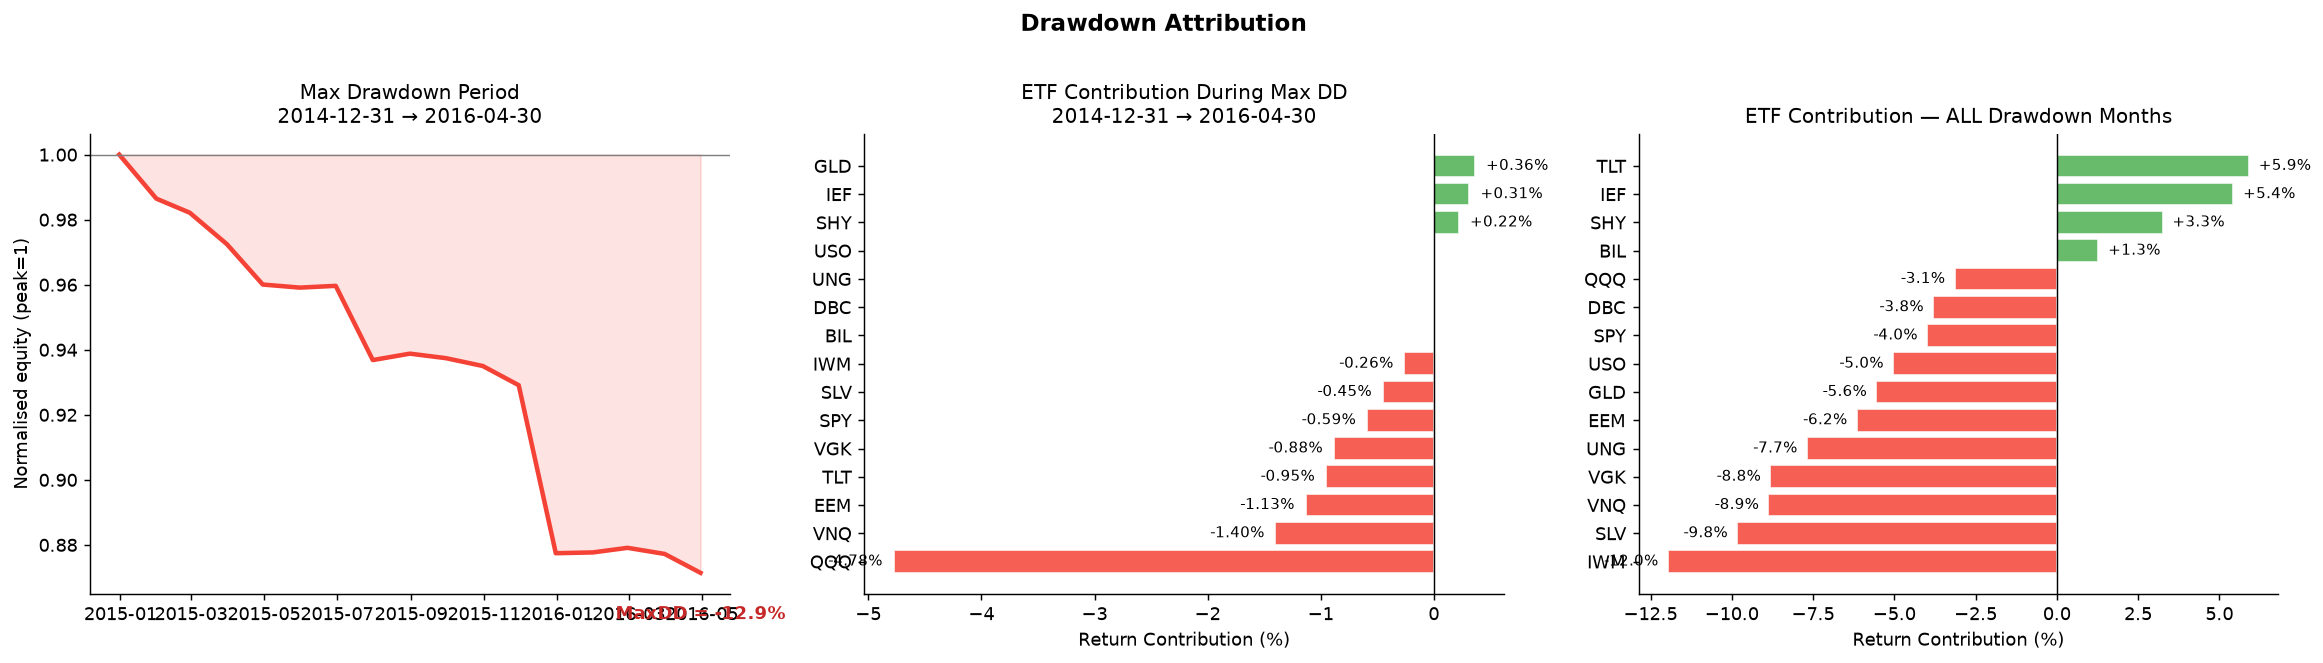

In [5]:
peak_dt, trough_dt = dd_res['max_dd_dates']
mdd_contrib  = dd_res['max_dd_contrib'] * 100
port_eq      = dd_res['portfolio_eq']
in_dd        = dd_res['in_dd_mask']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Max drawdown equity curve + annotation
ax = axes[0]
ep = port_eq.loc[peak_dt:trough_dt]
ep_norm = ep / ep.iloc[0]
ax.plot(ep_norm.index, ep_norm.values, color='#F44336', linewidth=2.5)
ax.fill_between(ep_norm.index, ep_norm.values, 1, alpha=0.15, color='#F44336')
ax.axhline(1, color='gray', linewidth=0.8)
mdd_val = (ep_norm.min() - 1) * 100
ax.text(ep_norm.idxmin(), ep_norm.min() - 0.01, f'MaxDD = {mdd_val:.1f}%',
        ha='center', va='top', fontsize=10, color='#C62828', fontweight='bold')
ax.set_title(f'Max Drawdown Period\n{peak_dt.date()} → {trough_dt.date()}')
ax.set_ylabel('Normalised equity (peak=1)')

# Waterfall: contribution during max DD
ax = axes[1]
mdd_c = mdd_contrib[active_tickers].sort_values()
cols  = ['#F44336' if v < 0 else '#4CAF50' for v in mdd_c.values]
ax.barh(mdd_c.index, mdd_c.values, color=cols, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for i, (tkr, v) in enumerate(mdd_c.items()):
    x = v - 0.1 if v < 0 else v + 0.1
    ha = 'right' if v < 0 else 'left'
    if abs(v) > 0.05:
        ax.text(x, i, f'{v:+.2f}%', va='center', ha=ha, fontsize=8.5)
ax.set_xlabel('Return Contribution (%)')
ax.set_title(f'ETF Contribution During Max DD\n{peak_dt.date()} → {trough_dt.date()}')

# All drawdown months contribution
ax = axes[2]
alldd_c = (dd_res['all_dd_contrib'] * 100)[active_tickers].sort_values()
cols2 = ['#F44336' if v < 0 else '#4CAF50' for v in alldd_c.values]
ax.barh(alldd_c.index, alldd_c.values, color=cols2, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for i, (tkr, v) in enumerate(alldd_c.items()):
    x = v - 0.3 if v < 0 else v + 0.3
    ha = 'right' if v < 0 else 'left'
    if abs(v) > 0.2:
        ax.text(x, i, f'{v:+.1f}%', va='center', ha=ha, fontsize=8.5)
ax.set_xlabel('Return Contribution (%)')
ax.set_title('ETF Contribution — ALL Drawdown Months')

fig.suptitle('Drawdown Attribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Efficiency Map — Return vs Risk per ETF

Each bubble = one ETF. Size = frequency in portfolio. X = risk contribution. Y = return contribution.

**Top right** = efficient (high return, reasonable risk). **Bottom right** = inefficient (high risk, low return).

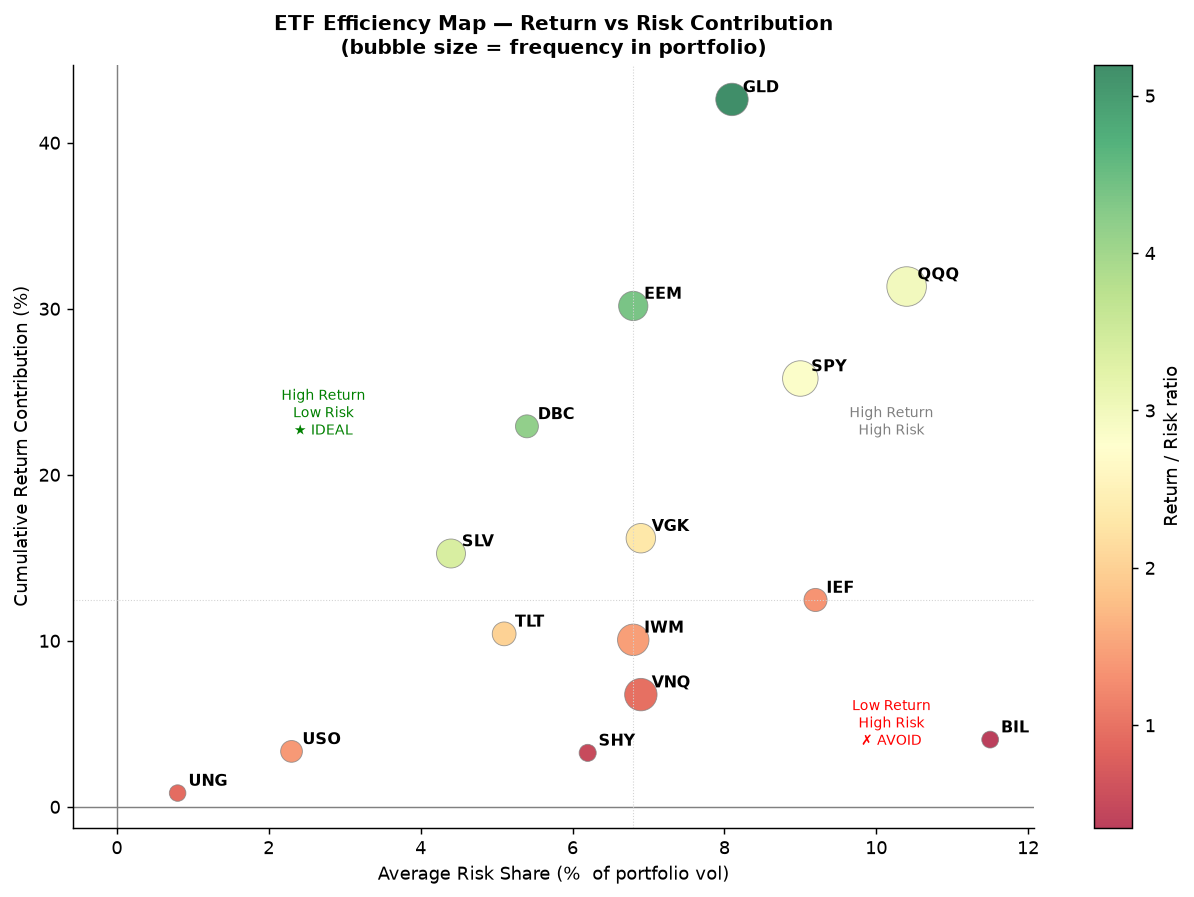

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

x_risk   = active['Risk Share %'].values
y_return = active['Cum Return Contrib %'].values
sizes    = active['Freq % (in portfolio)'].values * 8   # scale for bubble size
tickers_a = active.index.tolist()

sc = ax.scatter(x_risk, y_return, s=sizes, alpha=0.75,
                c=y_return / (x_risk + 0.1), cmap='RdYlGn', edgecolors='gray', linewidth=0.5)

for i, tkr in enumerate(tickers_a):
    ax.annotate(tkr, (x_risk[i], y_return[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=9, fontweight='bold')

# Diagonal reference line: equal return/risk efficiency
xmax = max(x_risk) * 1.05
xmin = 0
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)

# Quadrant shading
xmid = np.median(x_risk)
ymid = np.median(y_return)
ax.axhline(ymid, color='lightgray', linewidth=0.6, linestyle=':')
ax.axvline(xmid, color='lightgray', linewidth=0.6, linestyle=':')
ax.text(xmid * 1.5, ymid * 1.8, 'High Return\nHigh Risk', ha='center', color='gray', fontsize=8)
ax.text(xmid * 0.4, ymid * 1.8, 'High Return\nLow Risk\n★ IDEAL', ha='center', color='green', fontsize=8)
ax.text(xmid * 1.5, ymid * 0.3, 'Low Return\nHigh Risk\n✗ AVOID', ha='center', color='red', fontsize=8)

plt.colorbar(sc, label='Return / Risk ratio')
ax.set_xlabel('Average Risk Share (%  of portfolio vol)')
ax.set_ylabel('Cumulative Return Contribution (%)')
ax.set_title('ETF Efficiency Map — Return vs Risk Contribution\n(bubble size = frequency in portfolio)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Rolling Return Contribution — Top 5 ETFs

Shows which assets were driving returns at different points in time.

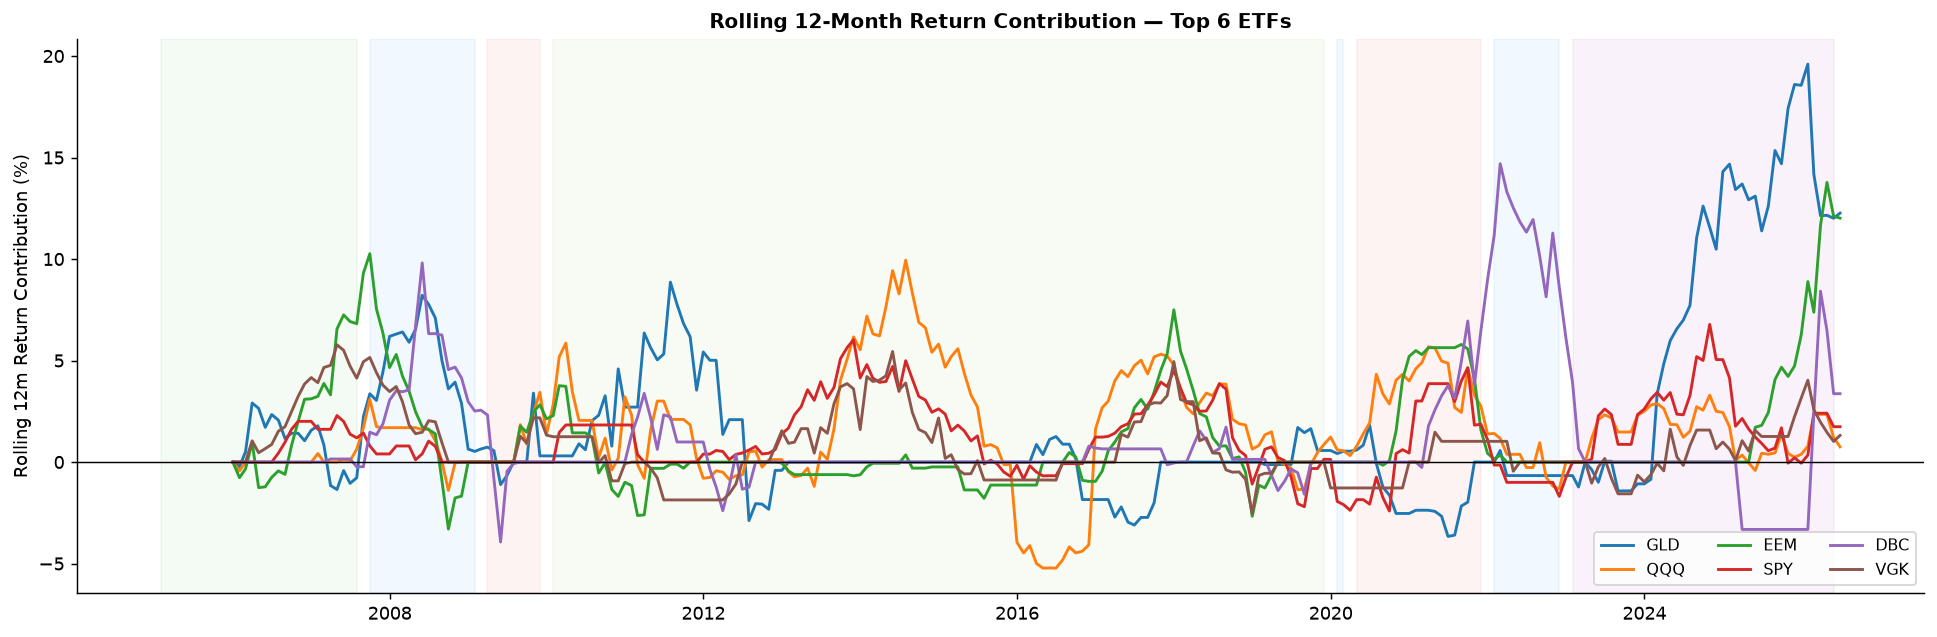

Key observation: Different ETFs lead in different regimes.
EEM/VGK drive returns in risk-on periods; GLD/TLT/IEF in risk-off periods.


In [7]:
# Pick top 6 contributors by cumulative return
top6 = summary.sort_values('Cum Return Contrib %', ascending=False).head(6).index.tolist()

fig, ax = plt.subplots(figsize=(15, 5))
palette = plt.cm.tab10.colors

for i, tkr in enumerate(top6):
    roll = ret_contrib[tkr].rolling(12).sum() * 100   # 12m rolling return contrib
    ax.plot(roll.index, roll.values, linewidth=1.6, label=tkr, color=palette[i])

ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(roll.index, 0, 0, alpha=0)  # for spacing

# Shade regime periods lightly
from src.regime_analysis import REGIMES, REGIME_COLOR
for name, (start, end) in REGIMES.items():
    c    = REGIME_COLOR[name]
    mask = (ret_contrib.index >= start) & (ret_contrib.index <= end)
    if mask.any():
        s = ret_contrib.index[mask][0]
        e = ret_contrib.index[mask][-1]
        ax.axvspan(s, e, alpha=0.06, color=c)

ax.set_ylabel('Rolling 12m Return Contribution (%)')
ax.set_title('Rolling 12-Month Return Contribution — Top 6 ETFs', fontweight='bold')
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

print('Key observation: Different ETFs lead in different regimes.')
print('EEM/VGK drive returns in risk-on periods; GLD/TLT/IEF in risk-off periods.')

## Summary Table

In [8]:
print('\n  ATTRIBUTION SUMMARY — All ETFs held ≥5% of months')
print(f"  {'ETF':<5} {'CumRet%':>8}  {'AnnRet%':>8}  {'RiskSh%':>8}  {'Freq%':>7}  {'AvgWt%':>7}  {'MaxDDC%':>8}  Verdict")
print('  ' + '─'*80)

# Average weight across all months
avg_wt_all = (active['Freq % (in portfolio)'] * active['Avg Wt When Held %'] / 100)
ratio = (active['Risk Share %'] / avg_wt_all).replace([np.inf,-np.inf], np.nan)

for tkr in active.sort_values('Cum Return Contrib %', ascending=False).index:
    row = active.loc[tkr]
    r   = ratio[tkr]
    flag = '★ STAR' if (row['Cum Return Contrib %'] > 15 and r < 1.3) else \
           ('⚠ EXPENSIVE' if r > 1.4 else \
           ('✗ DRAG' if row['Cum Return Contrib %'] < 0 else ''))
    print(f"  {tkr:<5} {row['Cum Return Contrib %']:>7.2f}%  "
          f"{row['Ann Return Contrib %']:>7.2f}%  "
          f"{row['Risk Share %']:>7.1f}%  "
          f"{row['Freq % (in portfolio)']:>6.1f}%  "
          f"{row['Avg Wt When Held %']:>6.1f}%  "
          f"{row['Max DD Contrib %']:>7.2f}%  {flag}")

print('\n  Three questions answered:')
top_ret = active.sort_values('Cum Return Contrib %', ascending=False).index[0]
top_risk = active[active['Freq % (in portfolio)'] >= 10].sort_values('Risk Share %', ascending=False).index[0]
hurt = active.sort_values('All DD Contrib %').index[0]
print(f'  1. Most return:  {top_ret} ({active.loc[top_ret, "Cum Return Contrib %"]:.1f}% cumulative)')
print(f'  2. Most risk:    {top_risk} ({active.loc[top_risk, "Risk Share %"]:.1f}% risk share)')
print(f'  3. Hurts most:   {hurt} ({active.loc[hurt, "All DD Contrib %"]:.1f}% contribution in drawdown months)')


  ATTRIBUTION SUMMARY — All ETFs held ≥5% of months
  ETF    CumRet%   AnnRet%   RiskSh%    Freq%   AvgWt%   MaxDDC%  Verdict
  ────────────────────────────────────────────────────────────────────────────────
  GLD     42.61%     1.98%      8.1%    40.3%    24.2%     0.36%  ★ STAR
  QQQ     31.34%     1.46%     10.4%    60.1%    17.0%    -4.78%  ★ STAR
  EEM     30.17%     1.40%      6.8%    32.9%    20.5%    -1.13%  ★ STAR
  SPY     25.80%     1.20%      9.0%    48.4%    19.7%    -0.59%  ★ STAR
  DBC     22.92%     1.07%      5.4%    20.2%    26.6%     0.00%  ★ STAR
  VGK     16.18%     0.75%      6.9%    33.3%    20.3%    -0.88%  ★ STAR
  SLV     15.26%     0.71%      4.4%    32.2%     9.5%    -0.45%  ⚠ EXPENSIVE
  IEF     12.46%     0.58%      9.2%    20.5%    41.2%     0.31%  
  TLT     10.42%     0.48%      5.1%    21.7%    18.7%    -0.95%  
  IWM     10.06%     0.47%      6.8%    38.0%    17.0%    -0.26%  
  VNQ      6.76%     0.32%      6.9%    40.3%    16.2%    -1.40%  
  BIL 